## 1. Load and Explore the Data

In [ ]:
from google.colab import drive
import pandas as pd

In [ ]:
# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = '/content/drive/MyDrive/Colab Notebooks/RED_ALERT_DATASET.txt'

# Load the data into pandas
df = pd.read_csv(file_path)  # Assuming tab-delimited text file
df.head()  # View the first few rows
# Check the shape of the dataset and basic statistics
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 176979 entries, 0 to 176978
Data columns (total 22 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   firstname                   176979 non-null  object 
 1   lastname                    176979 non-null  object 
 2   social_security_numbers     176979 non-null  int64  
 3   invoice_no                  176979 non-null  object 
 4   customer_no                 176979 non-null  object 
 5   principal_amount            176979 non-null  float64
 6   remaining_amount            176979 non-null  float64
 7   is_reminder_stopped         176979 non-null  int64  
 8   is_debt_collection_stopped  176979 non-null  int64  
 9   last_event_date             176979 non-null  object 
 10  last_event                  176979 non-null  object 
 11  period_start                176979 non-null  object 
 12  period_end                  176979 non-null  object 
 13  is_invoice    

,social_security_numbers,principal_amount,remaining_amount,is_reminder_stopped,is_debt_collection_stopped,is_invoice,mobile,postal_code,house_number,born_year
count,1.769790e+05,176979.000000,176979.000000,176979.000000,176979.000000,176979.000000,1.769790e+05,176979.00000,176979.000000,176979.000000
mean,5.048295e+09,1430.861970,846.171144,0.007368,0.007391,0.969657,2.121181e+08,45097.46631,147.084230,73.073348
std,2.877727e+09,2766.240479,2640.583391,0.085521,0.085651,0.171529,2.255899e+08,24626.18624,1546.767308,18.234763
min,0.000000e+00,-156.740000,-156.740000,0.000000,0.000000,0.000000,0.000000e+00,11115.00000,-1.000000,0.000000
25%,2.569779e+09,279.270000,0.000000,0.000000,0.000000,1.000000,0.000000e+00,21624.00000,3.000000,64.000000
50%,5.077359e+09,527.840000,0.000000,0.000000,0.000000,1.000000,0.000000e+00,42739.00000,8.000000,76.000000
75%,7.537696e+09,1261.045000,285.855000,0.000000,0.000000,1.000000,4.471635e+08,65463.00000,24.000000,86.000000
max,1.000000e+10,40545.030000,40545.030000,1.000000,1.000000,1.000000,4.999997e+08,98499.00000,88165.000000,99.000000


## **Anomaly Detection method**

# Isolation Forest

**Feature Selection** Rationale for Anomaly-Based Fraud Detection:

In designing the Isolation Forest model for fraud detection, I focused on selecting features that reflect both financial risk patterns and behavioral anomalies. The selected variables aim to capture signs of identity misuse, delayed payments, geographic concentrations, and abnormal financial transactions.



*   **principal_amount** – High-value transactions are commonly linked to fraud.

*   **remaining_amount** – Large unpaid balances may signal non-repayment risk.

*   **last_event_encoded** – Captures severity of final system event (e.g. DEBTCOLLECTION).

*   **same_address_different_name** – May indicate identity theft or synthetic identities.

*   **email_frequency** – Shared emails across customers can suggest fraudulent reuse.

*   **city_invoice_volume** – High volumes from certain cities may reflect fraud clusters.

*   **high_amount_and_reminder_stopped** – A dangerous combination of large spend and ignored reminders.

*   **is_debt_collection_stopped** – Disabling collection can reflect system manipulation.

*   **city_encoded** – Encodes location to detect geographic fraud trends.

*   **days_since_last_event** – Long silence after activity could indicate avoidance behavior.



In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# --- Load Data ---
df = pd.read_csv('processed_invoices_with_possible_fraud.csv')

# --- Preprocess date fields ---
df['last_event_date'] = pd.to_datetime(df['last_event_date'], errors='coerce')
df['period_start'] = pd.to_datetime(df['period_start'], errors='coerce')

# --- Feature: Days since last event ---
today = pd.Timestamp.today()
df['days_since_last_event'] = (today - df['last_event_date']).dt.days.fillna(0)

# --- Feature: Amount difference ---
df['amount_diff'] = df['principal_amount'] - df['remaining_amount']

# --- Feature: is_high_amount ---
high_amount_threshold = df['principal_amount'].quantile(0.90)
df['is_high_amount'] = (df['principal_amount'] > high_amount_threshold).astype(int)

# --- Feature: is_reminder_stopped (already binary) ---
df['is_reminder_stopped'] = df['is_reminder_stopped'].fillna(0).astype(int)
df['is_debt_collection_stopped'] = df['is_debt_collection_stopped'].fillna(0).astype(int)

# --- Feature: is_high_amount & is_reminder_stopped ---
df['high_amount_and_reminder_stopped'] = ((df['is_high_amount'] == 1) & (df['is_reminder_stopped'] == 1)).astype(int)

# --- Feature: City frequency ---
city_counts = df['city'].value_counts()
df['city_invoice_volume'] = df['city'].map(city_counts)

# --- Feature: Email frequency ---
email_counts = df['email'].value_counts()
df['email_frequency'] = df['email'].map(email_counts)

# --- Feature: Same address but different names ---
df['full_name'] = df['firstname'] + ' ' + df['lastname']
address_groups = df.groupby(['postal_code', 'street', 'house_number'])

df['same_address_different_name'] = address_groups['full_name'].transform('nunique') > 1
df['same_address_different_name'] = df['same_address_different_name'].astype(int)

# --- Feature: Encode last_event ---
event_map = {'INVOICE': 0, 'REMINDER': 1, 'DEBTCOLLECTION': 2}
df['last_event'] = df['last_event'].fillna('INVOICE')
df['last_event_encoded'] = df['last_event'].map(event_map)

# --- Encode city for modeling ---
df['city_encoded'] = LabelEncoder().fit_transform(df['city'].astype(str))

# --- Select final feature set ---
features = [
    'principal_amount',
    'remaining_amount',
    'last_event_encoded',
    'same_address_different_name',
    'email_frequency',
    'city_invoice_volume',
    'high_amount_and_reminder_stopped',
    'is_debt_collection_stopped',
    'city_encoded',
    'days_since_last_event'
]

# --- Fill NA and scale ---
df_model = df[features].fillna(0)
X_scaled = StandardScaler().fit_transform(df_model)

# --- Fit Isolation Forest ---
model = IsolationForest(contamination=0.01, random_state=42)
df['anomaly'] = model.fit_predict(X_scaled)

# --- Show detected anomalies ---
df_anomalies = df[df['anomaly'] == -1]
print(f"Number of anomalies detected: {len(df_anomalies)}")
print(df_anomalies[['customer_no', 'principal_amount', 'remaining_amount', 'last_event', 'anomaly']].head())

# --- Save updated dataset ---
df.to_csv('processed_invoices_with_possible_fraud.csv', index=False)


Number of anomalies detected: 1769
                                                  customer_no  \
216  f346ad6aaf7bfe8faabf6478c4c836b1043ed167d9006eef6ab29292   
236  a65aa9cbdf6e6efefca93add1a41eb331367d23a2a1f9afad5c6a2ab   
237  d4bc1dbbb660f686adab5b6bdbfc5d5c7f724766a63c9695e2720a87   
246  7c9c84047c3536b510a1b60e77e2f3500584959f0f530d5e043bd412   
321  43ca26d748ce025eae04b8a80dbf1a43e638583b5c0041bcd2063d37   

     principal_amount  remaining_amount      last_event  anomaly  
216          17804.66          17804.66  DEBTCOLLECTION       -1  
236          17383.22          17383.22  DEBTCOLLECTION       -1  
237          12609.87          12609.87  DEBTCOLLECTION       -1  
246          15354.39          15354.39  DEBTCOLLECTION       -1  
321          26802.76          26802.76  DEBTCOLLECTION       -1  


In [ ]:
#print(df[['customer_no', 'principal_amount', 'remaining_amount', 'last_event', 'anomaly','possible_fraud']].head())
print(df_anomalies[['customer_no', 'principal_amount', 'remaining_amount', 'last_event', 'anomaly','possible_fraud']].head())

                                                  customer_no  \
216  f346ad6aaf7bfe8faabf6478c4c836b1043ed167d9006eef6ab29292   
236  a65aa9cbdf6e6efefca93add1a41eb331367d23a2a1f9afad5c6a2ab   
237  d4bc1dbbb660f686adab5b6bdbfc5d5c7f724766a63c9695e2720a87   
246  7c9c84047c3536b510a1b60e77e2f3500584959f0f530d5e043bd412   
321  43ca26d748ce025eae04b8a80dbf1a43e638583b5c0041bcd2063d37   

     principal_amount  remaining_amount      last_event  anomaly  \
216          17804.66          17804.66  DEBTCOLLECTION       -1   
236          17383.22          17383.22  DEBTCOLLECTION       -1   
237          12609.87          12609.87  DEBTCOLLECTION       -1   
246          15354.39          15354.39  DEBTCOLLECTION       -1   
321          26802.76          26802.76  DEBTCOLLECTION       -1   

                                                                                                             possible_fraud  
216                                       Extremely High Spending / Same M

## Visualize the Anomalies

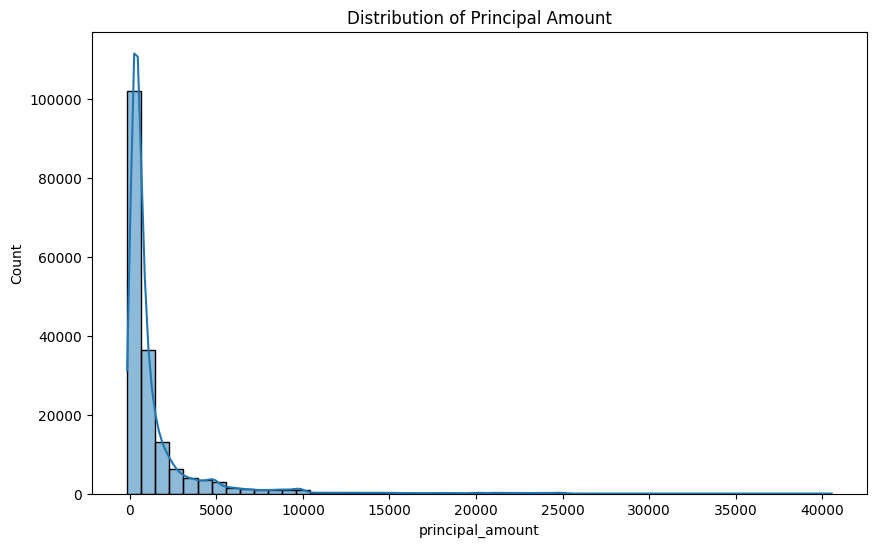

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['principal_amount'], bins=50, kde=True)
plt.title('Distribution of Principal Amount')
plt.show()


In [ ]:
import plotly.express as px

# Ensure anomaly label column exists
df['anomaly_label'] = df['anomaly'].map({1: 'Normal', -1: 'Anomaly'})

# Create the boxplot with color and hover details
fig = px.box(
    df,
    x='anomaly_label',
    y='principal_amount',
    color='anomaly_label',
    hover_data=['customer_no', 'possible_fraud', 'anomaly_label', 'remaining_amount'],
    title='Principal Amount by Anomaly Status',
    labels={
        'anomaly_label': 'Status',
        'principal_amount': 'Principal Amount',
        'remaining_amount': 'Remaining Amount'
    },
    color_discrete_map={'Normal': 'blue', 'Anomaly': 'red'},
    points='all'
)

fig.update_layout(showlegend=False)
fig.show()


In [ ]:
import plotly.express as px

# Make sure anomaly_label exists
df['anomaly_label'] = df['anomaly'].map({1: 'Normal', -1: 'Anomaly'})

# Create the interactive plot
fig = px.scatter(
    df,
    x='principal_amount',
    y='remaining_amount',
    color='anomaly_label',
    hover_data=['customer_no', 'possible_fraud'],
    title='Principal vs Remaining Amount with Anomaly Labels',
    labels={
        'principal_amount': 'Principal Amount',
        'remaining_amount': 'Remaining Amount',
        'anomaly_label': 'Status'
    },
    color_discrete_map={'Normal': 'blue', 'Anomaly': 'red'},
    opacity=0.6
)

fig.update_layout(legend_title_text='Anomaly Type')
fig.show()


## Explore patterns

Are the anomalies clustered around certain cities, born_years, or specific last_event_dates?

I can group and count anomalies per feature like this:

**Distribution of Anomalies by City**

<ipython-input-39-f87b6e0645aa>:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




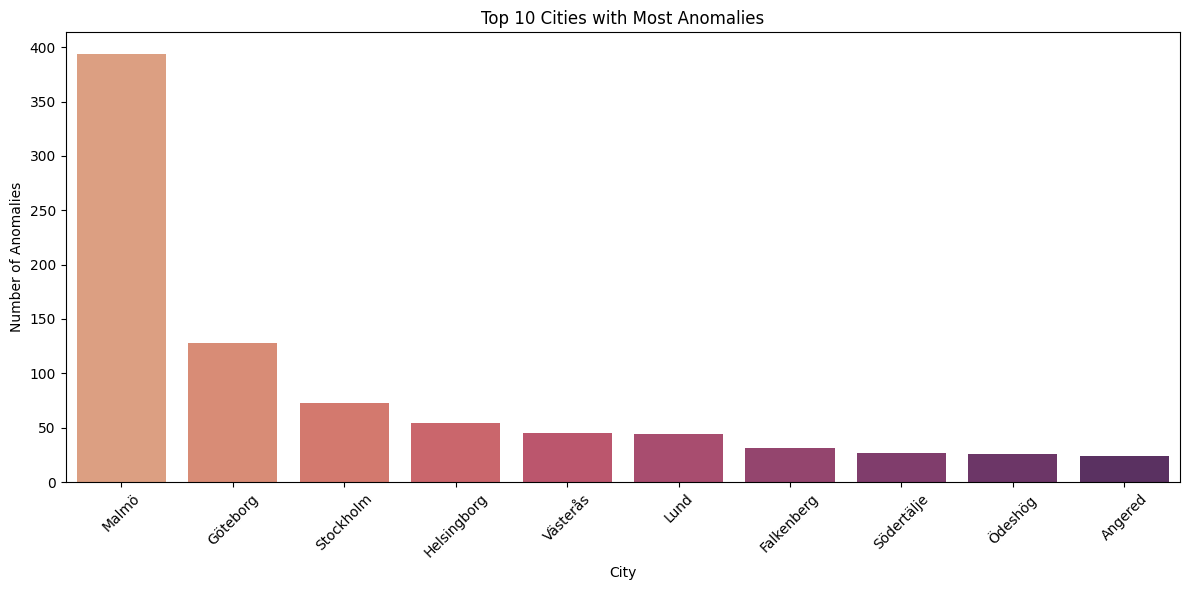

In [ ]:
ÍÍÍÍ(12, 6))
ÍÍÍÍmalies['city'].value_counts().nlargest(10)
ÍÍÍÍities.index, y=top_cities.values, palette="flare")
ÍÍÍÍities with Most Anomalies')
ÍÍÍÍof Anomalies')
plt.xlabel('City')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Anomalies by Gender**

<ipython-input-40-ab4ef858d3af>:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




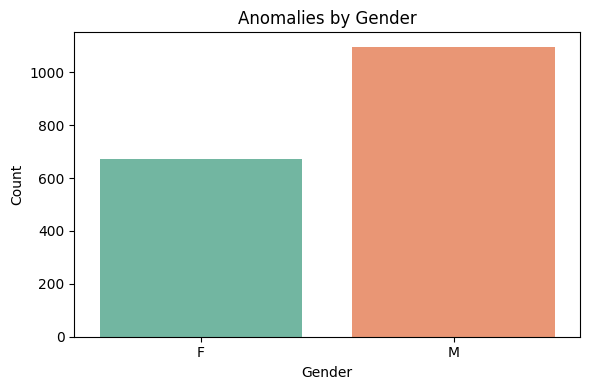

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_anomalies, x='gender', palette='Set2')
plt.title('Anomalies by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

**Distribution of Principal Amount in Anomalies**

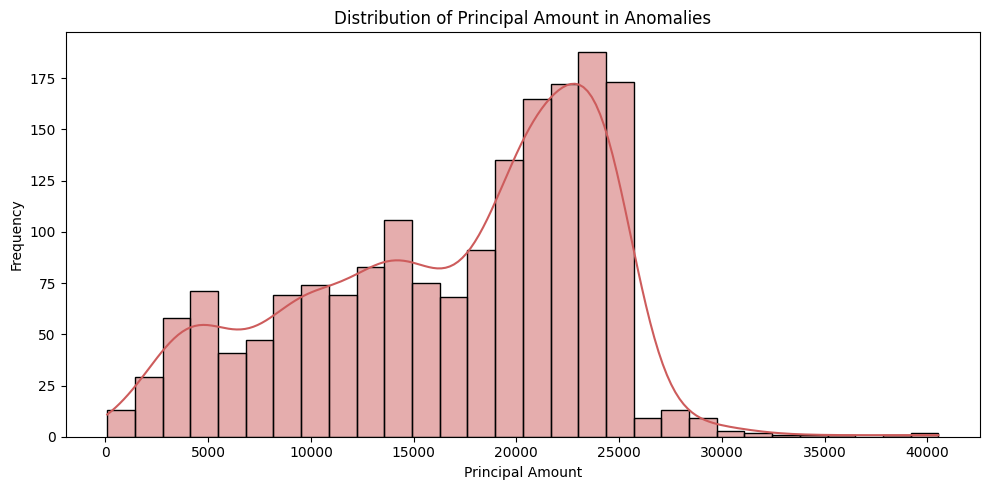

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(df_anomalies['principal_amount'], bins=30, kde=True, color='indianred')
plt.title('Distribution of Principal Amount in Anomalies')
plt.xlabel('Principal Amount')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

**Distribution of Anomalies by Age**

<ipython-input-42-4b5704de3a86>:19: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



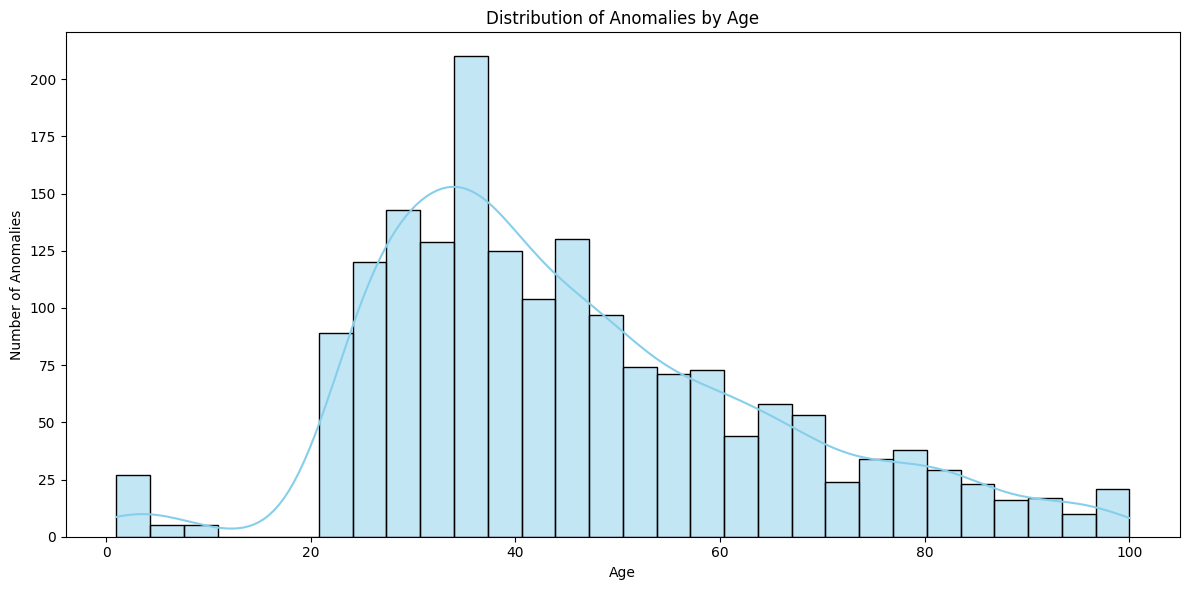

In [ ]:
from datetime import datetime

current_year = 2025

# Function to calculate the full birth year and age
def calculate_age(birth_year):
    if birth_year < 25:
        # Assume born in the 2000s
        full_birth_year = 2000 + birth_year
    else:
        # Assume born in the 1900s
        full_birth_year = 1900 + birth_year

    # Calculate age
    age = current_year - full_birth_year
    return age

# Use .loc[] to avoid SettingWithCopyWarning
df_anomalies.loc[:, 'age'] = df_anomalies['born_year'].apply(calculate_age)

# Plotting the anomalies based on age
plt.figure(figsize=(12, 6))
sns.histplot(df_anomalies['age'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Anomalies by Age')
plt.xlabel('Age')
plt.ylabel('Number of Anomalies')
plt.tight_layout()
plt.show()

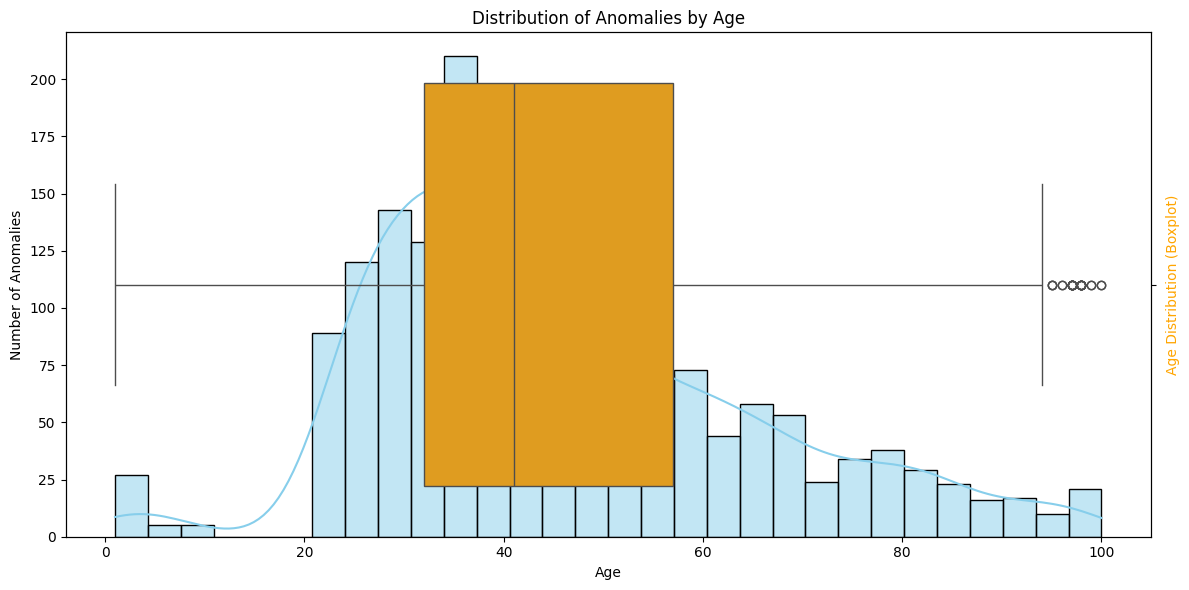

In [ ]:
current_year = 2025

# Function to calculate the full birth year and age
def calculate_age(birth_year):
    if birth_year < 25:
        # Assume born in the 2000s
        full_birth_year = 2000 + birth_year
    else:
        # Assume born in the 1900s
        full_birth_year = 1900 + birth_year

    # Calculate age
    age = current_year - full_birth_year
    return age

# Use .loc[] to avoid SettingWithCopyWarning
df_anomalies.loc[:, 'age'] = df_anomalies['born_year'].apply(calculate_age)

# Create figure and axes
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plotting the histogram
sns.histplot(df_anomalies['age'], bins=30, kde=True, color='skyblue', ax=ax1)
ax1.set_title('Distribution of Anomalies by Age')
ax1.set_xlabel('Age')
ax1.set_ylabel('Number of Anomalies')

# Create a second y-axis for the boxplot
ax2 = ax1.twinx()

# Plotting the box plot
sns.boxplot(x=df_anomalies['age'], color='orange', ax=ax2)
ax2.set_ylabel('Age Distribution (Boxplot)', color='orange')

# Adjust the layout for better readability
plt.tight_layout()

# Show the plot
plt.show()